<a href="https://colab.research.google.com/github/PrateekKumar135/LIGHTWEIGHt_CNN/blob/main/CNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow -q

In [2]:
import kagglehub
import os
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.models import Sequential
# from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

In [3]:
# Download latest version
path = kagglehub.dataset_download("mylee77/brain-tumor-mri-deduplicated-clean-version")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-deduplicated-clean-version' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-deduplicated-clean-version


In [4]:
# List the contents of the downloaded dataset directory
print(os.listdir(path))
print(path)

['brain-tumor-mri-deduplicated', 'data_preprocessing.py', 'Project_Report.pdf']
/kaggle/input/brain-tumor-mri-deduplicated-clean-version


In [5]:

dataset_root = os.path.join(path, 'brain-tumor-mri-deduplicated')
print(dataset_root)
print(os.listdir(dataset_root))

# Create a separate path for 'External_Test' data, assuming it also has a 'PNG' subfolder
# external_test_path = os.path.join(dataset_root, 'External_Test', 'PNG')
# print(f"External Test data path: {external_test_path}")
# shutil.move(external_test_path, dataset_root)
###################################################################

/kaggle/input/brain-tumor-mri-deduplicated-clean-version/brain-tumor-mri-deduplicated
['data']


# Step 1: Explore the dataset

In [6]:
data_dir = os.path.join(dataset_root, "data")
print(os.listdir(data_dir))

['val', 'test', 'train']


# Step 2: Check class folders

In [7]:
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")

print("Training classes:")
print(os.listdir(train_dir))

print("\nTesting classes:")
print(os.listdir(test_dir))

print("\nValidation classes:")
print(os.listdir(val_dir))

Training classes:
['pituitary', 'notumor', 'meningioma', 'glioma']

Testing classes:
['pituitary', 'notumor', 'meningioma', 'glioma']

Validation classes:
['pituitary', 'notumor', 'meningioma', 'glioma']


# Step 3: Count images in each class

In [8]:
for folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, folder)
    print(folder, len(os.listdir(class_path)))

pituitary 1215
notumor 820
meningioma 1237
glioma 1258


In [9]:
for folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, folder)
    print(folder, len(os.listdir(class_path)))

pituitary 400
notumor 303
meningioma 390
glioma 382


# Step 4: Visualize sample images

In [10]:
# import matplotlib.pyplot as plt
# from PIL import Image

# classes = os.listdir(train_dir)

# plt.figure(figsize=(12,8))

# for i, cls in enumerate(classes):
#     img_name = os.listdir(os.path.join(train_dir, cls))[0]
#     img_path = os.path.join(train_dir, cls, img_name)

#     img = Image.open(img_path)

#     plt.subplot(2,2,i+1)
#     plt.imshow(img, cmap='gray')
#     plt.title(cls)
#     plt.axis("off")

# plt.show()

# Step 5: Check image sizes

In [11]:
sizes = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path)[:20]:
        img = Image.open(os.path.join(class_path, img_name))
        sizes.append(img.size)

print(set(sizes))

{(600, 519), (200, 252), (512, 512), (201, 251), (504, 540), (225, 225), (216, 216), (210, 264), (550, 664), (192, 192), (230, 282), (206, 244), (275, 301), (339, 340), (680, 680), (442, 454), (256, 256), (441, 442)}


In [12]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [14]:
# source_train = train_dir
# destination_train = "/kaggle/working/Training"

# shutil.copytree(source_train, destination_train)

# print("Copied successfully!")

# Before Augmentation

In [15]:
for cls in os.listdir(train_dir):
    print(cls, len(os.listdir(os.path.join(train_dir, cls))))

pituitary 1215
notumor 820
meningioma 1237
glioma 1258


**Count images in each class**

In [16]:
class_counts = {}

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    class_counts[cls] = count

print(class_counts)

{'pituitary': 1215, 'notumor': 820, 'meningioma': 1237, 'glioma': 1258}


**Find the largest class**

In [17]:
target_count = max(class_counts.values())

print("Target images per class:", target_count)

Target images per class: 1258


In [18]:
# from tensorflow.keras.preprocessing.image import load_img, img_to_array
train_dir = "/kaggle/working/Training"
for cls in os.listdir(train_dir):

    class_path = os.path.join(train_dir, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
        and "_aug_" not in f
    ]

    current_count = len(images)

    print(f"\nProcessing {cls}")
    print(f"Current images: {current_count}")

    if current_count >= target_count:
        print("Already balanced.")
        continue

    img_index = 0

    while current_count < target_count:

        image_name = images[img_index % len(images)]

        image_path = os.path.join(class_path, image_name)

        img = load_img(image_path)

        x = img_to_array(img)

        x = x.reshape((1,) + x.shape)

        prefix = os.path.splitext(image_name)[0] + "_aug"

        for batch in train_datagen.flow(
                x,
                batch_size=1,
                save_to_dir=class_path,
                save_prefix=prefix,
                save_format="jpg"):

            current_count += 1

            if current_count >= target_count:
                break

        img_index += 1

    print(f"Final images: {current_count}")


Processing meningioma
Current images: 1237
Final images: 1258

Processing notumor
Current images: 820
Final images: 1258

Processing pituitary
Current images: 1215
Final images: 1258

Processing glioma
Current images: 1258
Already balanced.


**Verify the result**

In [19]:
for cls in os.listdir(train_dir):

    class_path = os.path.join(train_dir, cls)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{cls}: {count}")

meningioma: 1279
notumor: 1654
pituitary: 1301
glioma: 1258


In [20]:

conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

conv_base.summary()

/tmp/ipykernel_82505/804963405.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base = MobileNetV2(


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [21]:

model = Sequential([
    conv_base,

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    # Dense(100, activation='relu'),
    Dropout(0.3),
    # Dense(50, activation='relu'),
    # Dropout(0.1),
    Dense(4, activation='softmax')
])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,356 (10.00 MB)

 Trainable params: 2,585,732 (9.86 MB)

 Non-trainable params: 34,624 (135.25 KB)

In [23]:
conv_base.trainable = True
for layer in conv_base.layers[:-40]:
    layer.trainable = False

In [24]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = train_dir,
    labels='inferred',
    label_mode = 'categorical',
    batch_size=50,
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = test_dir,
    labels='inferred',
    label_mode = 'categorical',
    batch_size=50,
    image_size=(150,150)
)

Found 5492 files belonging to 4 classes.
Found 1475 files belonging to 4 classes.


In [25]:
# Normalize

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def process(image, label):
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [26]:
# for images, labels in train_ds.take(1):

#     print("Minimum :", tf.reduce_min(images).numpy())
#     print("Maximum :", tf.reduce_max(images).numpy())

#     break

In [27]:
# import matplotlib.pyplot as plt

# # Get one batch
# for images, labels in train_ds.take(20):

#     print("Image batch shape:", images.shape)
#     print("Label batch shape:", labels.shape)

#     # Display the first image
#     plt.figure(figsize=(5,5))
#     plt.imshow(images[0])
#     plt.title(f"Label: {labels[0].numpy()}")
#     plt.axis("off")
#     plt.show()

#     break

In [28]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy',
                                                                        tf.keras.metrics.Precision(name='precision'),
                                                                        tf.keras.metrics.Recall(name='recall')])

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.4232 - loss: 1.5925 - precision: 0.4593 - recall: 0.3501 - val_accuracy: 0.4007 - val_loss: 1.3397 - val_precision: 0.4861 - val_recall: 0.1898
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.6045 - loss: 1.0229 - precision: 0.6687 - recall: 0.5384 - val_accuracy: 0.5634 - val_loss: 1.0854 - val_precision: 0.6663 - val_recall: 0.4007
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.7125 - loss: 0.7535 - precision: 0.7621 - recall: 0.6615 - val_accuracy: 0.6400 - val_loss: 0.9241 - val_precision: 0.7330 - val_recall: 0.5397
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7680 - loss: 0.6153 - precision: 0.8141 - recall: 0.7183 - val_accuracy: 0.6861 - val_loss: 0.8210 - val_precision: 0.7607 - val_recall: 0.6163
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.8066 - loss: 0.5217 - precision: 0.8468 - recall: 0.7728 - val_accuracy: 0.7166 - val_los

In [30]:
# history = model.fit(train_ds,epochs=25,validation_data=validation_ds)

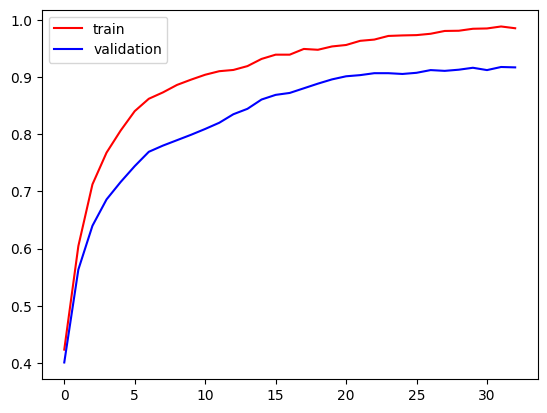

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

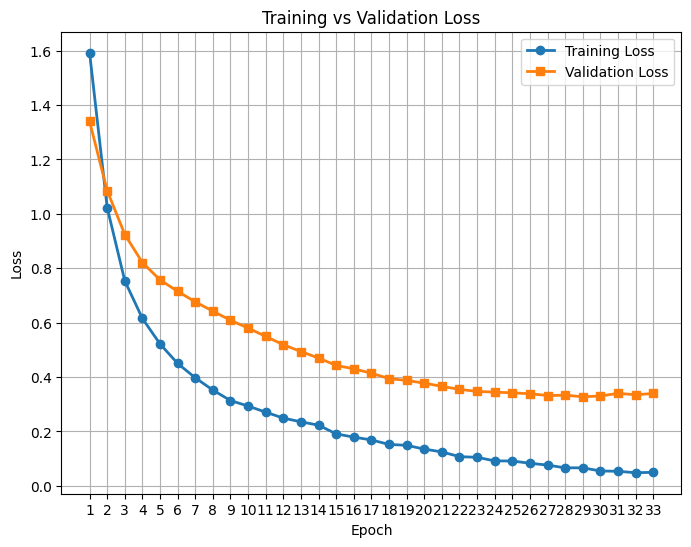

In [32]:
# import matplotlib.pyplot as plt

# Extract values from history
# train_accuracy = history.history['accuracy']
# val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

# ---------------- Loss Plot ----------------
plt.figure(figsize=(8,6))

plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, marker='s', linewidth=2, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()